# Tutorial: 机器学习基础与 AI 协作建模

**课程**：Python 进阶 · 计算机学院 · CloudStudio + CodeBuddy

**受众**：有 Python + Pandas 基础、希望用 AI 驱动 ML 建模的同学

**前置条件**：会 Python 基础语法；已安装 scikit-learn

## 学习目标

- 掌握四类 ML 任务：回归、分类、聚类、降维
- 理解 sklearn 统一 API：fit / predict / score / transform
- 用两段式 Prompt 快速生成完整 ML 流程代码
- 掌握线性回归（RMSE）、SVM（F1 + 决策边界）、K-means（肘部法则）、PCA（降维可视化）
- 了解 Spec-driven 开发范式，能编写 speckit.md 管理 ML 项目

## 课程大纲

1. ML 基础理论（AI/ML/DL 关系、工作流程、四类任务）
2. 任务1：线性回归（学习时间预测成绩）
3. 任务2：SVM 分类（鸢尾花 + 决策边界）
4. 任务3：K-means 聚类（客户分群 + 肘部法则）
5. 任务4：PCA 降维（鸢尾花可视化）
6. 进阶：Spec-driven 开发范式与 ML 项目规约化

---
## Part 0：机器学习基础理论

### 0.1 人工智能、机器学习、深度学习的关系

```
人工智能（AI）
  └─ 机器学习（ML）
       └─ 深度学习（DL）
```

- **人工智能**：使计算机能够完成通常需要人类智能的任务的技术
- **机器学习**：AI 的一个实现途径，从数据中自动学习
- **深度学习**：机器学习的一个方法，基于神经网络

> 本讲聚焦机器学习的基础算法，不涉及深度学习

### 0.2 什么是机器学习？

**传统编程思路**：规则 + 数据 → 答案

**机器学习思路**：数据 + 答案 → 规则（模型）

> 机器学习从数据中自动发现模式，而非人工编写规则

### 0.3 机器学习三要素

| 要素 | 作用 |
|---|---|
| **数据** | AI 的"燃料"，样本 + 标签 |
| **算法** | 模型如何学习（线性回归、SVM、决策树等）|
| **算力** | CPU 适合 IO 密集型，GPU 适合计算密集型 |

> "数据和特征决定了机器学习的上限，模型只是逼近这个上限。"（吴恩达）

### 0.4 机器学习工作流程

```
数据 → 特征工程 → 模型训练 → 模型评估 → 服务部署
              ↑___________________________↓
                    迭代优化
```

1. **获取数据**：样本 + 标签
2. **数据预处理**：缺失值、异常值处理
3. **特征工程**：特征提取、转换、降维
4. **模型训练**：fit(X, y)
5. **模型评估**：accuracy、F1-score、RMSE 等
6. **迭代优化**：调整超参数、增加数据

### 0.5 数据集结构：特征矩阵 X + 标签向量 y

**鸢尾花数据集示例**：

| sepal length | sepal width | petal length | petal width | label |
|---|---|---|---|---|
| 5.1 | 3.5 | 1.4 | 0.2 | 0 |
| 7.0 | 3.2 | 4.7 | 1.4 | 1 |
| 6.3 | 3.3 | 6.0 | 2.5 | 2 |

- **特征矩阵 X**：n_samples × n_features（150 × 4）
- **标签向量 y**：n_samples（150）
- **样本**：一行数据
- **特征**：一列数据（样本的属性）

### 0.6 机器学习的四类任务

| 任务类型 | 输入 | 输出 | 是否有标签 | 举例 |
|---|---|---|---|---|
| **分类** | 特征 X | 离散类别 | ✓ 有（监督）| 垃圾邮件检测 |
| **回归** | 特征 X | 连续数值 | ✓ 有（监督）| 房价预测 |
| **聚类** | 特征 X | 数据分组 | ✗ 无（无监督）| 客户分群 |
| **降维** | 高维特征 | 低维特征 | ✗ 无（无监督）| 数据可视化 |

> 监督学习更符合人类认知，现实应用中绝大多数任务是监督学习

### 0.7 sklearn 统一 API

```python
model = SomeModel(**hyperparams)      # 初始化
model.fit(X_train, y_train)           # 训练（无监督只有 X）
y_pred = model.predict(X_test)        # 预测
score = model.score(X_test, y_test)   # 评估
```

| 算法 | 类 | 导入路径 | 任务类型 |
|---|---|---|---|
| 线性回归 | `LinearRegression` | `sklearn.linear_model` | 回归 |
| SVM | `SVC` | `sklearn.svm` | 分类 |
| K-means | `KMeans` | `sklearn.cluster` | 聚类 |
| PCA | `PCA` | `sklearn.decomposition` | 降维 |

In [110]:
# 环境初始化
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets

# 中文字体
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 随机种子（Rules 规定：必须设置）
RANDOM_STATE = 42

print('scikit-learn 环境就绪 ✓')

scikit-learn 环境就绪 ✓


---
## Part 1：线性回归（监督学习 - 回归）

### 1.0 线性回归理论基础

**回归任务**：输入特征 X → 预测连续数值 y

**简单线性回归模型**：y = ax + b

- x：输入特征（学习时间）
- y：输出（成绩）
- a：回归系数（斜率）
- b：截距

**目标**：找到最佳 a、b，使得预测值 ŷ 尽可能接近真实值 y

### 1.0.1 损失函数（MSE）

```
MSE = (1/m) × Σ(y⁽ⁱ⁾ - ŷ⁽ⁱ⁾)²
```

- m：样本数
- y⁽ⁱ⁾：第 i 个样本的真实值
- ŷ⁽ⁱ⁾：第 i 个样本的预测值

**目标**：最小化 MSE

### 1.0.2 梯度下降法

```
θ = θ - η × ∇L(θ)
```

- θ：模型参数（a, b）
- η：学习率（步长）
- ∇L(θ)：损失函数的梯度

用"下山"比喻：学习率=步长，梯度=最陡方向

### 1.0.3 回归评估指标

| 指标 | 公式 | 说明 |
|---|---|---|
| **MSE** | (1/m) × Σ(y - ŷ)² | 均方误差，量纲变化 |
| **RMSE** | √MSE | 均方根误差，与 y 同量纲 |
| **MAE** | (1/m) × Σ|y - ŷ| | 平均绝对误差 |
| **R²** | 1 - MSE/Var(y) | 判定系数，[-∞, 1]，越接近 1 越好 |

**数据**：`data.xlsx` — 学习时间 → 学生成绩

### 1.1 加载并查看数据

In [111]:
# 加载实验数据
df = pd.read_excel('实验二/data.xlsx')
print('数据形状:', df.shape)
print('列名:', df.columns.tolist())
print('\n前5行:')
print(df.head())

# 提取特征和标签
time = df['学习时间'].values      # 学习时间（小时）
score = df['成绩'].values        # 成绩（分）

数据形状: (20, 2)
列名: ['学习时间', '成绩']

前5行:
   学习时间  成绩
0  0.50  10
1  0.75  22
2  1.00  13
3  1.25  43
4  1.50  20


### 1.2 reshape(-1, 1) 的含义

**sklearn 要求 X 是二维矩阵**，单特征也要转成列向量

In [112]:
# reshape(-1, 1)：把一维数组转为列向量
time_2d = time.reshape(-1, 1)
print('原始形状:', time.shape)      # (20,)
print('reshape后:', time_2d.shape)  # (20, 1)

# 解释：-1 表示自动计算行数，1 表示列数为 1

原始形状: (20,)
reshape后: (20, 1)


### 1.3 训练线性回归模型

In [113]:
from sklearn.linear_model import LinearRegression

# 初始化并训练
model = LinearRegression()
model.fit(time_2d, score)

# 获取参数
b = model.intercept_       # 截距
k = model.coef_[0]         # 回归系数

print(f'回归方程: y = {k:.2f}x + {b:.2f}')
print(f'回归系数 k = {k:.2f}')
print(f'截距 b = {b:.2f}')

回归方程: y = 16.21x + 8.52
回归系数 k = 16.21
截距 b = 8.52


### 1.4 计算 RMSE（均方根误差）

In [114]:
from sklearn.metrics import mean_squared_error

# 预测
pre_score = model.predict(time_2d)

# RMSE
rmse = np.sqrt(mean_squared_error(score, pre_score))
print(f'RMSE = {rmse:.2f}')

# 解释：RMSE 是预测偏差的量纲感知值，越小越好

RMSE = 9.85


### 1.5 绘制回归结果

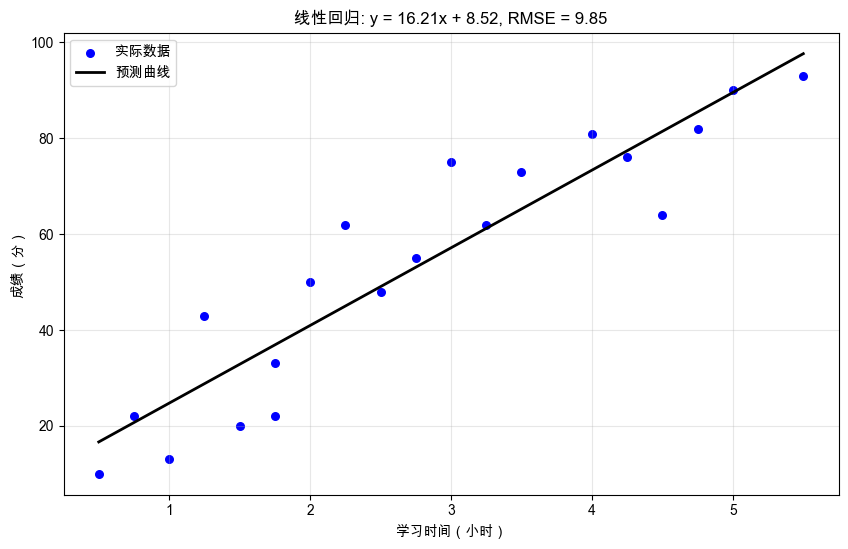

In [115]:
# 散点图：实际数据蓝色，预测线黑色
plt.figure(figsize=(10, 6))
plt.scatter(time, score, color='b', label='实际数据', s=30)
plt.plot(time, pre_score, color='black', linewidth=2, label='预测曲线')
plt.xlabel('学习时间（小时）')
plt.ylabel('成绩（分）')
plt.title(f'线性回归: y = {k:.2f}x + {b:.2f}, RMSE = {rmse:.2f}')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

---
## Part 2：SVM 分类（监督学习 - 分类）

### 2.0 SVM 理论基础

**分类任务**：输入特征 X → 预测离散类别 y

#### 2.0.1 支持向量机（SVM）原理

**核心思想**：找到最大间隔的超平面

```
         支持向量
            ↓
    ○ ○    |    ● ●
      ○    |    ●
           |
  ─────────┼───────── 超平面
           |
      ●    |    ○
    ● ●    |    ○ ○
            ↑
         支持向量
```

- **超平面**：分类决策边界
- **支持向量**：距离超平面最近的样本点
- **间隔**：支持向量到超平面的距离

**目标**：最大化间隔

#### 2.0.2 核函数

**核函数**：将数据映射到高维空间，使线性不可分变为线性可分

| 核函数 | 公式 | 适用场景 |
|---|---|---|
| **线性核** | K(x, x') = x^T · x' | 线性可分 |
| **多项式核** | K(x, x') = (ax^T · x' + b)^d | 非线性 |
| **高斯核（RBF）** | K(x, x') = exp(-γ||x-x'||²) | 最常用，映射到无穷维 |

> 高斯核（RBF）是最常用的核函数，适合大多数非线性数据

#### 2.0.3 混淆矩阵

| | 预测为正 | 预测为负 |
|---|---|---|
| **实际为正** | TP（真阳性）| FN（假阴性）|
| **实际为负** | FP（假阳性）| TN（真阴性）|

**示例**：癌症预测
- TP：实际患癌，预测患癌（正确）
- FN：实际患癌，预测健康（漏诊）
- FP：实际健康，预测患癌（误诊）
- TN：实际健康，预测健康（正确）

#### 2.0.4 精确率、召回率、F1-score

| 指标 | 公式 | 含义 | 关注场景 |
|---|---|---|---|
| **精确率 P** | TP / (TP + FP) | 预测为正中，真正正例的比例 | 宁可漏诊，不可误诊 |
| **召回率 R** | TP / (TP + FN) | 实际为正中，被找到的比例 | 宁可误诊，不可漏诊 |
| **F1-score** | 2PR / (P + R) | P 和 R 的调和平均 | 兼顾两者 |

**准确率的陷阱**：癌症预测准确率 99.9%，但召回率=0（没找到任何癌症患者）

> **结论**：准确率高 ≠ 模型好。必须看 P/R/F1

**数据**：150样本 × 4特征 → 3类鸢尾花

### 2.1 加载鸢尾花数据集

In [116]:
# 加载鸢尾花数据集
iris = datasets.load_iris()

print('keys:', iris.keys())
print('特征名:', iris.feature_names)
print('类别名:', iris.target_names)
print('数据形状:', iris.data.shape)   # (150, 4)

data = iris.data
target = iris.target

keys: dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
特征名: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
类别名: ['setosa' 'versicolor' 'virginica']
数据形状: (150, 4)


### 2.2 划分训练/测试集

In [117]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    data, target, test_size=0.1, random_state=0
)  # Rules 规定：必须设 random_state

print(f'训练集样本数: {len(X_train)}')
print(f'测试集样本数: {len(X_test)}')

训练集样本数: 135
测试集样本数: 15


### 2.3 训练 SVM 分类器（rbf 核）

In [118]:
from sklearn import svm

# rbf 核（高斯核）适合非线性数据
clf = svm.SVC(kernel='rbf', C=100)
clf.fit(X_train, y_train)

# 预测
y_pred = clf.predict(X_test)
print('预测结果:', y_pred)
print('真实标签:', y_test)

预测结果: [2 1 0 2 0 2 0 1 1 1 2 1 1 1 1]
真实标签: [2 1 0 2 0 2 0 1 1 1 2 1 1 1 1]


### 2.4 计算 F1-score

In [119]:
from sklearn.metrics import f1_score

# F1-score（多分类用 micro）
f1 = f1_score(y_pred, y_test, average='micro')
print(f'F1-score: {f1:.2f}')

# 解释：micro = 全局计算 P/R；macro = 各类分别算再平均

F1-score: 1.00


### 2.5 绘制特征散点图（按类别上色）

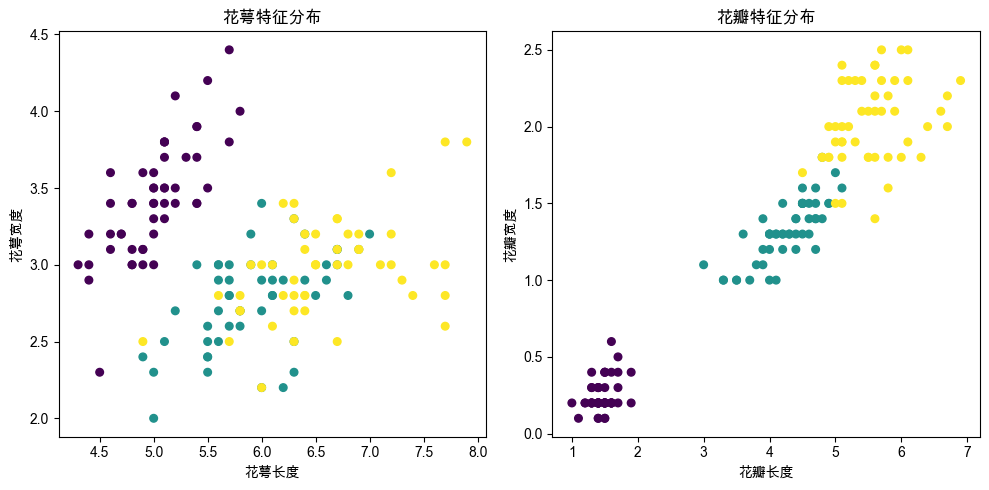

In [120]:
# 花萼长度/宽度散点图
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(data[:, 0], data[:, 1], c=target, cmap='viridis', s=30)
plt.xlabel('花萼长度')
plt.ylabel('花萼宽度')
plt.title('花萼特征分布')

# 花瓣长度/宽度散点图
plt.subplot(1, 2, 2)
plt.scatter(data[:, 2], data[:, 3], c=target, cmap='viridis', s=30)
plt.xlabel('花瓣长度')
plt.ylabel('花瓣宽度')
plt.title('花瓣特征分布')

plt.tight_layout()
plt.show()

### 2.6 决策边界可视化

**核心思路**：铺网格 → 预测每个点 → 画等高线

In [121]:
# 辅助函数：生成网格
def make_meshgrid(x, y, h=.02):
    x_min, x_max = x.min() - 1, x.max() + 1
    y_min, y_max = y.min() - 1, y.max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    return xx, yy

# 辅助函数：绘制决策边界
def plot_contours(ax, clf, xx, yy, **params):
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    out = ax.contour(xx, yy, Z, **params)
    return out

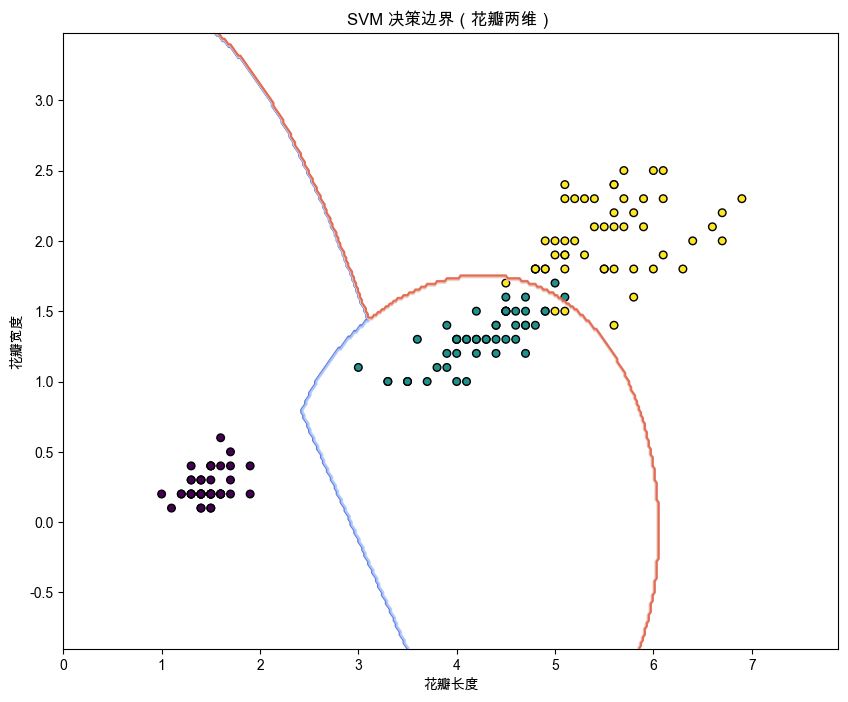

In [122]:
# 取花瓣（petal）长宽两维
petal_data = data[:, 2:]   # 第2、3列
X0, X1 = petal_data[:, 0], petal_data[:, 1]
xx, yy = make_meshgrid(X0, X1)

# 用花瓣两维训练 SVM
clf_petal = svm.SVC(kernel='rbf', C=100)
clf_petal.fit(petal_data, target)

# 绘制决策边界
fig, ax = plt.subplots(figsize=(10, 8))
plot_contours(ax, clf_petal, xx, yy, alpha=0.8, cmap='coolwarm')
ax.scatter(X0, X1, c=target, cmap='viridis', s=30, edgecolors='k')
ax.set_xlabel('花瓣长度')
ax.set_ylabel('花瓣宽度')
ax.set_title('SVM 决策边界（花瓣两维）')
plt.show()

---
## Part 3：K-means 聚类（无监督学习）

### 3.0 K-means 理论基础

**聚类任务**：输入特征 X → 发现数据分组（无标签）

#### 3.0.1 K-means 算法原理

**目标**：将 n 个样本划分为 k 个簇

**算法步骤**：
1. 随机初始化 k 个聚类中心
2. 将每个样本分配到最近的聚类中心
3. 重新计算每个簇的中心（样本均值）
4. 重复 2-3 直到中心不再变化

**损失函数**：
```
J = Σᵢ Σⱼ ||x⁽ⁱ⁾ - μⱼ||²
```
- μⱼ：第 j 个簇的中心
- 目标：最小化 J（各样本到中心的距离平方和）

#### 3.0.2 肘部法则确定 K

**问题**：K 取多少合适？

**肘部法则**：
- 绘制 loss（inertia_）随 K 变化的曲线
- 找"拐点最明显"处作为 K 值（loss 下降突然变缓的点）

```
loss
  │  ●
  │   ●
  │    ●
  │     ● ← 拐点
  │      ●
  │       ●
  │        ●
  └──────────── K
    2 3 4 5 6 7 8 9
```

#### 3.0.3 K-means 优缺点

| 优点 | 缺点 |
|---|---|
| 原理简单，易于实现 | 需要预先指定 K |
| 收敛速度快 | 对初始中心敏感 |
| 可解释性强 | 对异常点敏感 |
| | 只能发现球形簇 |

**数据**：`mall_customers.csv` — 200客户 × 4特征

### 3.1 加载并预处理数据

In [123]:
# 加载客户数据
df_customers = pd.read_csv('实验二/mall_customers.csv')
print('数据形状:', df_customers.shape)
print('列名:', df_customers.columns.tolist())
print('\n前5行:')
print(df_customers.head())

# 性别预处理为 0/1
df_customers['Genre'] = (df_customers['Genre'] == 'Male').astype(int)

# 提取特征
data_cluster = df_customers[['Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']].values

数据形状: (200, 4)
列名: ['Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

前5行:
    Genre  Age  Annual Income (k$)  Spending Score (1-100)
0    Male   19                  15                      39
1    Male   21                  15                      81
2  Female   20                  16                       6
3  Female   23                  16                      77
4  Female   31                  17                      40


### 3.2 肘部法则确定 K

**问题**：K 取多少合适？用 loss（inertia_）随 K 变化曲线找拐点

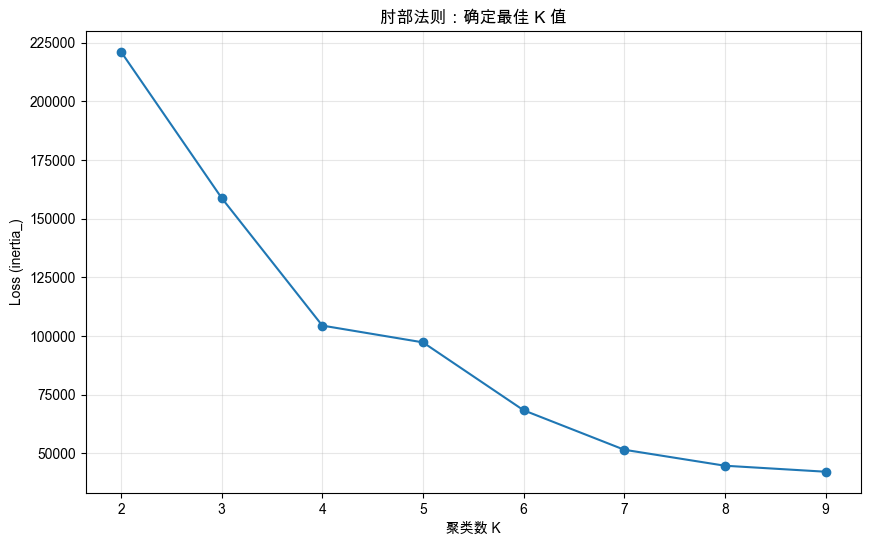

提示：找拐点最明显处作为 K 值


In [124]:
from sklearn.cluster import KMeans

# 肘部法则：K 从 2 到 9
loss = []
for i in range(2, 10):
    model = KMeans(n_clusters=i, random_state=RANDOM_STATE)
    model.fit(data_cluster)
    loss.append(model.inertia_)   # inertia_ = 各样本到中心的距离平方和

# 绘制肘部曲线
plt.figure(figsize=(10, 6))
plt.plot(range(2, 10), loss, marker='o')
plt.xlabel('聚类数 K')
plt.ylabel('Loss (inertia_)')
plt.title('肘部法则：确定最佳 K 值')
plt.grid(alpha=0.3)
plt.show()

print('提示：找拐点最明显处作为 K 值')

### 3.3 训练 K-means（选定 K=5）

In [125]:
# 选定 K=5（示例，实际根据肘部曲线判断）
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=RANDOM_STATE)
kmeans.fit(data_cluster)

# 获取聚类标签
labels = kmeans.labels_
print('聚类标签:', labels[:20])

# 获取聚类中心
centers = kmeans.cluster_centers_
print('聚类中心形状:', centers.shape)

聚类标签: [2 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2]
聚类中心形状: (5, 4)


### 3.4 3D 散点图可视化

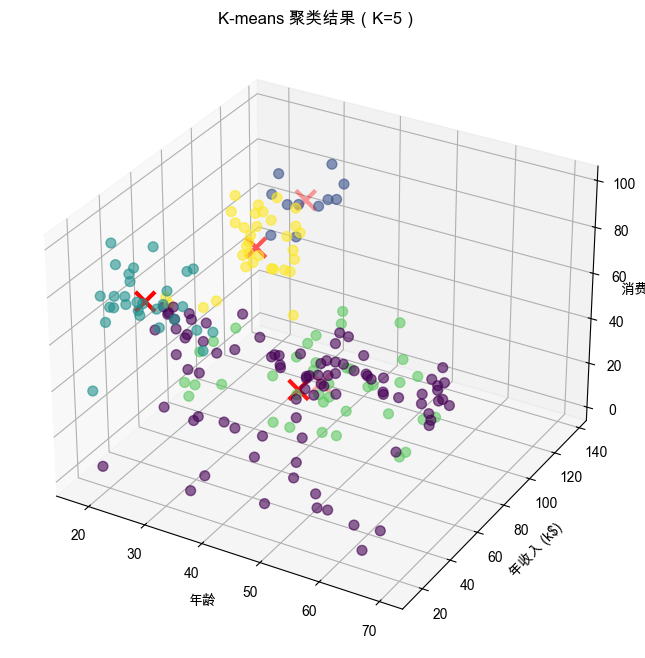

提示：不同颜色代表不同客户群体，可用于差异化营销


In [126]:
# 3D 散点图
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# 绘制数据点（按聚类标签上色）
ax.scatter(df_customers['Age'],
           df_customers['Annual Income (k$)'],
           df_customers['Spending Score (1-100)'],
           c=labels, cmap='viridis', s=50, alpha=0.6)

# 绘制聚类中心
ax.scatter(centers[:, 1], centers[:, 2], centers[:, 3],
           c='red', marker='x', s=200, linewidths=3)

ax.set_xlabel('年龄')
ax.set_ylabel('年收入 (k$)')
ax.set_zlabel('消费评分')
ax.set_title('K-means 聚类结果（K=5）')
plt.show()

print('提示：不同颜色代表不同客户群体，可用于差异化营销')

---
## Part 4：PCA 降维（无监督学习）

### 4.0 PCA 理论基础

**降维任务**：高维特征 → 低维特征（无标签）

**目的**：
- 数据可视化（高维 → 2D/3D）
- 减少计算量
- 去除噪声
- 保留关键信息

#### 4.0.1 PCA 原理（主成分分析）

**核心思想**：找到方差最大的方向

**步骤**：
1. 去中心化（坐标原点移到数据中心）
2. 找方差最大方向 = 第一主成分
3. 与第一主成分正交且方差次大 = 第二主成分
4. 以此类推

**降维标准**：信息损失最小，即方差最大

#### 4.0.2 PCA 数学原理

**协方差矩阵**：
```
C = (1/m) X^T X
```

**特征值分解**：
```
C v = λ v
```
- v：特征向量（主成分方向）
- λ：特征值（该方向的方差）

**选择前 k 个主成分**：按特征值从大到小排序，选择前 k 个特征向量

#### 4.0.3 PCA 为什么要先标准化？

**不标准化的后果**：量纲大的特征（如年收入 20000）主导主成分方向，量纲小的特征（如年龄 30）被忽略

**标准化**：x_scaled = (x - μ) / σ

> PCA 前必须 StandardScaler

#### 4.0.4 解释方差比

**explained_variance_ratio_**：每个主成分解释的方差比例

累计解释方差 = 保留的信息量。通常选择累计方差达到 85%-95% 的维度。

**目标**：把 4 维特征降到 2 维，便于可视化

### 4.1 PCA 为什么要先标准化？

不标准化的后果：量纲大的特征会主导主成分方向

In [127]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 先标准化
data_std = StandardScaler().fit_transform(data)

print('标准化前均值:', data.mean(axis=0).round(3))
print('标准化后均值:', data_std.mean(axis=0).round(3))
print('标准化后标准差:', data_std.std(axis=0).round(3))

标准化前均值: [5.843 3.057 3.758 1.199]
标准化后均值: [-0. -0. -0. -0.]
标准化后标准差: [1. 1. 1. 1.]


### 4.2 PCA 降到 2 维

In [128]:
# PCA 降到 2 维
pca = PCA(n_components=2)
components = pca.fit_transform(data_std)

print('降维后形状:', components.shape)   # (150, 2)
print('各主成分解释方差比:', pca.explained_variance_ratio_)
print('累计解释方差:', pca.explained_variance_ratio_.sum())

降维后形状: (150, 2)
各主成分解释方差比: [0.72962445 0.22850762]
累计解释方差: 0.9581320720000164


### 4.3 降维结果可视化

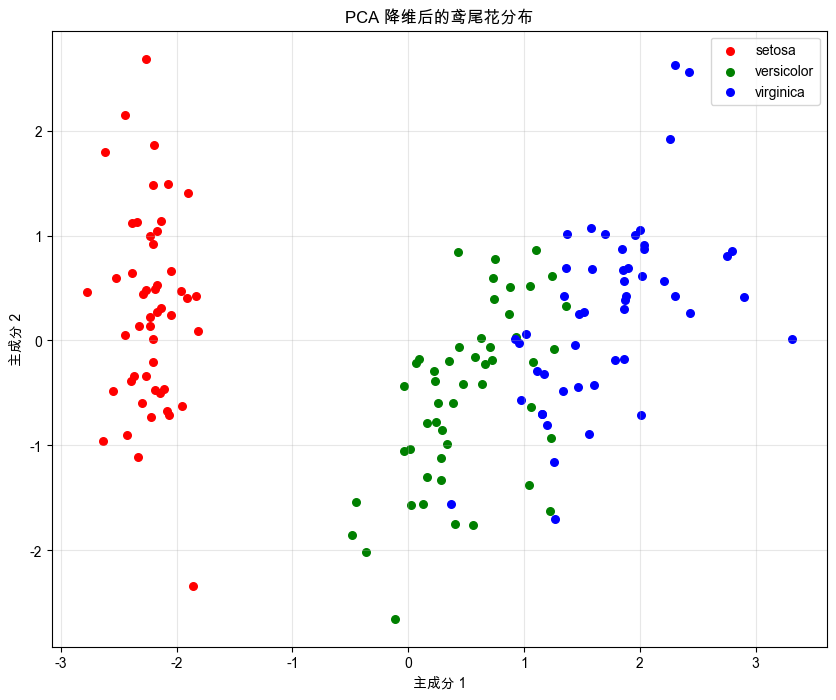

提示：降维后三类鸢尾花在二维平面上仍能较好分离


In [129]:
# 拼接成 DataFrame
final_data = pd.DataFrame(components, columns=['component 1', 'component 2'])
final_data['target'] = target

# 按类别绘制散点图
targets = [0, 1, 2]
colors = ['r', 'g', 'b']
labels_name = iris.target_names

plt.figure(figsize=(10, 8))
for t, c, name in zip(targets, colors, labels_name):
    mask = final_data['target'] == t
    plt.scatter(final_data.loc[mask, 'component 1'],
                final_data.loc[mask, 'component 2'],
                c=c, s=30, label=name)

plt.xlabel('主成分 1')
plt.ylabel('主成分 2')
plt.title('PCA 降维后的鸢尾花分布')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print('提示：降维后三类鸢尾花在二维平面上仍能较好分离')

---
## Part 5：Spec-driven 开发范式与 ML 项目规约化

### 5.1 从 Vibe Coding 到 Spec-driven

前四个任务中我们用的都是**两段式 Prompt**（Round 1 描述任务，Round 2 加约束）。这在单个任务中表现不错，但面对多步骤项目时存在短板：

- 每次新开对话，之前的约束全部丢失
- AI 上下文窗口有限，复杂项目容易前后矛盾
- 同一份约束（如 random_state、StandardScaler 前置）要反复在 Prompt 中重写

**Spec-driven（规约驱动）** 的思路很简单：
- 先把"做什么、不能做什么、验收标准"写进一个文件（`speckit.md`）
- 每次对话通过 `@speckit.md` 引用，AI 自动遵守全部约束
- 维护项目 = 维护规约，而非逐条重复 Prompt

> Speckit 是 GitHub 开源的 Spec-driven 开发工具（111k+ stars），核心流程：constitution → specify → plan → tasks → implement

### 5.2 speckit.md 的三段式结构

```markdown
# 客户画像分析 Speckit

## constitution（不可违反的硬约束）
- 禁止在全量数据上 fit StandardScaler（防数据泄露）
- 聚类前必须用肘部法则确定 K，不得凭感觉指定
- 所有随机过程必须设置 random_state=42
- PCA 前必须先 StandardScaler
- 评估分类模型必须输出 F1-score

## context（数据背景 + 分析目标）
数据：mall_customers.csv，200 名购物中心客户
字段：CustomerID、Genre（Male/Female）、Age、Annual Income(k$)、Spending Score(1-100)
目标：对客户分群，找出消费行为相似的群体，并用 PCA 2D 图验证分群质量

## 任务列表（可执行、可验证的步骤）
- [ ] 任务1：加载数据，性别编码为 0/1，打印形状和前5行
- [ ] 任务2：肘部法则确定 K（K=2-9，绘制 inertia 曲线，标注拐点）
- [ ] 任务3：K-means++（选定 K，random_state=42），绘制 3D 散点
- [ ] 任务4：StandardScaler + PCA 降至 2 维，按聚类标签上色
```

### 5.3 Speckit 与两段式 Prompt 的对比

| | 两段式 Prompt | Speckit |
|---|---|---|
| **适合** | 单任务、一次性建模 | 多环节项目、跨对话保持约束 |
| **优点** | 简单快速 | 约束不重复，AI 全程遵守 constitution |
| **缺点** | 新开对话约束断掉 | 需要额外写 speckit.md |
| **ML 场景** | 单算法快速验证 | 完整建模项目（探查→建模→评估→可视化）|

> 两者不冲突：Speckit 管全局约束，两段式 Prompt 管单步执行

In [130]:
# 演示：speckit.md 中的 constitution 约束
# 实际使用时，这些内容写入 speckit.md 文件，通过 @speckit.md 引用

print('=== ML 项目 Constitution 示例 ===')
print()
constitution = [
    '1. 禁止在全量数据上 fit StandardScaler（防数据泄露）',
    '2. 聚类前必须用肘部法则确定 K，不得凭感觉指定',
    '3. 所有随机过程必须设置 random_state=42',
    '4. PCA 前必须先 StandardScaler',
    '5. 评估分类模型必须输出 F1-score，禁止只看 accuracy',
]
for rule in constitution:
    print(f'  {rule}')

print()
print('=== 使用方式 ===')
print('  Step 1: 把 constitution + context + 任务列表写入 speckit.md')
print('  Step 2: 每次 Prompt 附加 @speckit.md 引用')
print('  Step 3: AI 自动遵守全部约束，无需每次重复')
print()
print('示例 Prompt:')
print('  @speckit.md @mall_customers.csv 用肘部法则确定 K')
print('  @speckit.md 对聚类特征做 StandardScaler，PCA 降至 2 维')

=== ML 项目 Constitution 示例 ===

  1. 禁止在全量数据上 fit StandardScaler（防数据泄露）
  2. 聚类前必须用肘部法则确定 K，不得凭感觉指定
  3. 所有随机过程必须设置 random_state=42
  4. PCA 前必须先 StandardScaler
  5. 评估分类模型必须输出 F1-score，禁止只看 accuracy

=== 使用方式 ===
  Step 1: 把 constitution + context + 任务列表写入 speckit.md
  Step 2: 每次 Prompt 附加 @speckit.md 引用
  Step 3: AI 自动遵守全部约束，无需每次重复

示例 Prompt:
  @speckit.md @mall_customers.csv 用肘部法则确定 K
  @speckit.md 对聚类特征做 StandardScaler，PCA 降至 2 维


In [131]:
# Speckit 完整流程命令速查
print('=== Speckit 完整流程（适合中大型 ML 项目）===')
print()

speckit_commands = {
    '/speckit.constitution': '定义项目底线原则（防数据泄露、指定评估指标等）',
    '/speckit.specify':      '用业务语言描述需求（只说 WHAT，不说 HOW）',
    '/speckit.clarify':      '对模糊点提问，补齐边界条件',
    '/speckit.plan':         '生成技术方案（算法选型、数据流设计）',
    '/speckit.tasks':        '拆解为可执行的任务列表',
    '/speckit.analyze':      '检查 spec/plan/tasks 的一致性',
    '/speckit.implement':    '按任务顺序落地代码',
}

for cmd, desc in speckit_commands.items():
    print(f'  {cmd:<25} → {desc}')

print()
print('=== 课程实验中的简化用法 ===')
print('  手写 speckit.md（constitution + context + 任务列表）')
print('  每条任务执行时用 @speckit.md 引用即可')
print()
print('核心收益：约束写一次，全程生效；项目越复杂，收益越大')

=== Speckit 完整流程（适合中大型 ML 项目）===

  /speckit.constitution     → 定义项目底线原则（防数据泄露、指定评估指标等）
  /speckit.specify          → 用业务语言描述需求（只说 WHAT，不说 HOW）
  /speckit.clarify          → 对模糊点提问，补齐边界条件
  /speckit.plan             → 生成技术方案（算法选型、数据流设计）
  /speckit.tasks            → 拆解为可执行的任务列表
  /speckit.analyze          → 检查 spec/plan/tasks 的一致性
  /speckit.implement        → 按任务顺序落地代码

=== 课程实验中的简化用法 ===
  手写 speckit.md（constitution + context + 任务列表）
  每条任务执行时用 @speckit.md 引用即可

核心收益：约束写一次，全程生效；项目越复杂，收益越大


---
## 小结

### ML 四类任务速查表

| 任务 | 算法 | API | 说明 |
|---|---|---|---|
| 回归 | `LinearRegression` | `fit(X, y)` | X 必须二维 |
| 分类 | `SVC` | `fit(X, y)` + `predict(X)` | F1-score 评估 |
| 聚类 | `KMeans` | `fit(X)` + `labels_` | 无监督，只有 X |
| 降维 | `PCA` | `fit_transform(X)` | 先标准化 |

### Vibe Coding 工具速查表

| 工具 | ML 场景用途 |
|---|---|
| 两段式 Prompt | Round 1 描述任务类型，Round 2 指定指标和输出 |
| Speckit / speckit.md | constitution + context + 任务列表，通过 @引用注入约束 |
| @文件引用 | 让 AI 了解数据列名和 speckit.md 规约 |
| reshape(-1, 1) | 单特征转列向量，sklearn 要求 X 二维 |
| 肘部法则 | K-means 的 K 值选择，找 loss 曲线拐点 |
| StandardScaler | PCA/SVM/KNN 前必须标准化 |
| 决策边界 | 网格 + predict + contour 可视化分类器 |
| Inline Edit | 局部修改已有代码（换算法、改指标） |

### Speckit 关键概念速查表

| 概念 | 含义 |
|---|---|
| constitution | 不可违反的硬约束（如禁止数据泄露、必须设 random_state） |
| context | 数据背景 + 分析目标（帮助 AI 理解项目全貌） |
| 任务列表 | 可执行、可验证的步骤（勾选式管理进度） |
| @speckit.md | 每次 Prompt 引用规约文件，AI 自动遵守全部约束 |

---

> **核心公式**：ML 工程化 = 两段式 Prompt（单任务） + Speckit（多步骤项目） + 可视化验证